# Parte 2: Optimización combinatoria (TSP México)

Objetivo: encontrar el orden óptimo para visitar las 32 capitales estatales de México
usando:
- Algoritmo Genético (GA)
- Colonia de Hormigas (ACO)

Función de costo por tramo i→j:
Costo(i,j) = CostoCombustible(i,j) + CostoPeaje(i,j) + CostoTiempo(i,j)

donde:
- CostoCombustible = (dist_km / rendimiento_km_l) * precio_gasolina
- CostoPeaje = factor_peaje * dist_km
- CostoTiempo = valor_hora * (dist_km / velocidad_promedio)

In [11]:
# ==========================================================
# CELDA 1: Imports
# ==========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from math import radians, sin, cos, atan2, sqrt
import random

In [12]:
# ==========================================================
# CELDA 2: Dataset de 32 capitales (lat/lon aproximadas)
# ==========================================================
# Puedes ajustar coordenadas si el profe exige precisión mayor.

capitales = [
    ("Aguascalientes", 21.8853, -102.2916),
    ("Mexicali", 32.6245, -115.4523),
    ("La Paz", 24.1426, -110.3128),
    ("San Francisco de Campeche", 19.8450, -90.5230),
    ("Tuxtla Gutiérrez", 16.7528, -93.1167),
    ("Chihuahua", 28.6329, -106.0691),
    ("Saltillo", 25.4267, -100.9954),
    ("Colima", 19.2433, -103.7250),
    ("Durango", 24.0277, -104.6532),
    ("Toluca", 19.2826, -99.6557),
    ("Guanajuato", 21.0190, -101.2574),
    ("Chilpancingo", 17.5515, -99.5006),
    ("Pachuca", 20.1011, -98.7591),
    ("Guadalajara", 20.6597, -103.3496),
    ("Morelia", 19.7060, -101.1950),
    ("Cuernavaca", 18.9242, -99.2216),
    ("Tepic", 21.5095, -104.8957),
    ("Monterrey", 25.6866, -100.3161),
    ("Oaxaca", 17.0732, -96.7266),
    ("Puebla", 19.0414, -98.2063),
    ("Querétaro", 20.5888, -100.3899),
    ("Chetumal", 18.5002, -88.2961),
    ("San Luis Potosí", 22.1565, -100.9855),
    ("Culiacán", 24.8091, -107.3940),
    ("Hermosillo", 29.0729, -110.9559),
    ("Villahermosa", 17.9892, -92.9475),
    ("Ciudad Victoria", 23.7369, -99.1411),
    ("Tlaxcala", 19.3182, -98.2375),
    ("Xalapa", 19.5438, -96.9102),
    ("Mérida", 20.9674, -89.5926),
    ("Zacatecas", 22.7709, -102.5832),
    ("Ciudad de México", 19.4326, -99.1332),
]

df_ciudades = pd.DataFrame(capitales, columns=["ciudad", "lat", "lon"])
n = len(df_ciudades)
print("Número de ciudades:", n)
df_ciudades.head()

Número de ciudades: 32


,ciudad,lat,lon
0,Aguascalientes,21.8853,-102.2916
1,Mexicali,32.6245,-115.4523
2,La Paz,24.1426,-110.3128
3,San Francisco de Campeche,19.8450,-90.5230
4,Tuxtla Gutiérrez,16.7528,-93.1167


In [13]:
# ==========================================================
# CELDA 3: Distancia Haversine (km)
# ==========================================================
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

dist_km = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i != j:
            dist_km[i, j] = haversine_km(
                df_ciudades.loc[i, "lat"], df_ciudades.loc[i, "lon"],
                df_ciudades.loc[j, "lat"], df_ciudades.loc[j, "lon"]
            )

In [14]:
# ==========================================================
# CELDA 4: Parámetros del problema (ajustables)
# ==========================================================
# Define tu carro aquí (ejemplo):
carro = {
    "nombre": "Nissan Versa 1.6",
    "rendimiento_km_l": 16.0,   # km por litro en carretera
}

precio_gasolina = 24.0          # MXN/litro
velocidad_prom_kmh = 85.0       # km/h
factor_peaje_mxn_km = 0.85      # aproximación global (puedes justificar)

# Parámetro a estudiar (valor hora vendedor):
valores_hora = [100, 200, 300]  # MXN/h

In [15]:
# ==========================================================
# CELDA 5: Matriz de costo total para un valor_hora dado
# ==========================================================
def construir_matriz_costo(dist_km, valor_hora, rendimiento_km_l, precio_gasolina, velocidad_kmh, factor_peaje):
    # combustible por km
    costo_comb_km = precio_gasolina / rendimiento_km_l
    # tiempo por km
    costo_tiempo_km = valor_hora / velocidad_kmh
    # peaje por km (aprox)
    costo_peaje_km = factor_peaje

    costo_km = costo_comb_km + costo_tiempo_km + costo_peaje_km
    C = dist_km * costo_km
    np.fill_diagonal(C, 0.0)
    return C, costo_km

In [16]:
# ==========================================================
# CELDA 6: Utilidades TSP
# ==========================================================
def costo_ruta(ruta, C):
    total = 0.0
    for i in range(len(ruta)-1):
        total += C[ruta[i], ruta[i+1]]
    total += C[ruta[-1], ruta[0]]  # regreso a inicio
    return total

def distancia_ruta_km(ruta, D):
    total = 0.0
    for i in range(len(ruta)-1):
        total += D[ruta[i], ruta[i+1]]
    total += D[ruta[-1], ruta[0]]
    return total

def ruta_a_nombres(ruta, df):
    return [df.loc[i, "ciudad"] for i in ruta]

In [17]:
# ==========================================================
# CELDA 7: Algoritmo Genético (implementación propia)
# ==========================================================
def crossover_ox(p1, p2):
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))
    child = [-1]*n
    child[a:b+1] = p1[a:b+1]
    fill = [x for x in p2 if x not in child]
    idx = 0
    for i in range(n):
        if child[i] == -1:
            child[i] = fill[idx]
            idx += 1
    return child

def mut_swap(route, p=0.2):
    r = route.copy()
    if random.random() < p:
        i, j = random.sample(range(len(r)), 2)
        r[i], r[j] = r[j], r[i]
    return r

def torneo(poblacion, fitness, k=3):
    idxs = random.sample(range(len(poblacion)), k)
    best = min(idxs, key=lambda i: fitness[i])
    return poblacion[best]

def ga_tsp(C, pop_size=120, n_gen=500, p_mut=0.25, elite=5, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    n = C.shape[0]

    poblacion = [random.sample(range(n), n) for _ in range(pop_size)]

    best_hist = []
    best_route = None
    best_cost = np.inf

    for g in range(n_gen):
        fitness = [costo_ruta(ind, C) for ind in poblacion]

        gen_best_idx = int(np.argmin(fitness))
        if fitness[gen_best_idx] < best_cost:
            best_cost = fitness[gen_best_idx]
            best_route = poblacion[gen_best_idx].copy()

        best_hist.append(best_cost)

        # elitismo
        elite_idx = np.argsort(fitness)[:elite]
        nueva = [poblacion[i].copy() for i in elite_idx]

        while len(nueva) < pop_size:
            p1 = torneo(poblacion, fitness, k=3)
            p2 = torneo(poblacion, fitness, k=3)
            h = crossover_ox(p1, p2)
            h = mut_swap(h, p=p_mut)
            nueva.append(h)

        poblacion = nueva

    return best_route, best_cost, best_hist

In [18]:
# ==========================================================
# CELDA 8: ACO (implementación propia)
# ==========================================================
def elegir_siguiente(ciudad_actual, no_visitadas, tau, eta, alpha, beta):
    probs = []
    cand = list(no_visitadas)
    for j in cand:
        probs.append((tau[ciudad_actual, j]**alpha) * (eta[ciudad_actual, j]**beta))
    probs = np.array(probs, dtype=float)
    probs = probs / probs.sum()
    return np.random.choice(cand, p=probs)

def aco_tsp(C, n_ants=40, n_iter=300, alpha=1.0, beta=4.0, rho=0.5, Q=100.0, seed=42):
    np.random.seed(seed)
    n = C.shape[0]

    # visibilidad (heurística): eta = 1/costo
    eta = np.where(C > 0, 1.0/(C + 1e-12), 0.0)
    tau = np.ones((n, n), dtype=float)

    best_route = None
    best_cost = np.inf
    best_hist = []

    for it in range(n_iter):
        rutas_iter = []
        costos_iter = []

        for _ in range(n_ants):
            start = np.random.randint(0, n)
            ruta = [start]
            no_visitadas = set(range(n))
            no_visitadas.remove(start)

            actual = start
            while no_visitadas:
                nxt = elegir_siguiente(actual, no_visitadas, tau, eta, alpha, beta)
                ruta.append(nxt)
                no_visitadas.remove(nxt)
                actual = nxt

            c = costo_ruta(ruta, C)
            rutas_iter.append(ruta)
            costos_iter.append(c)

            if c < best_cost:
                best_cost = c
                best_route = ruta.copy()

        # evaporación
        tau = (1 - rho) * tau

        # depósito
        for ruta, c in zip(rutas_iter, costos_iter):
            deposit = Q / (c + 1e-12)
            for i in range(len(ruta)-1):
                a, b = ruta[i], ruta[i+1]
                tau[a, b] += deposit
                tau[b, a] += deposit
            tau[ruta[-1], ruta[0]] += deposit
            tau[ruta[0], ruta[-1]] += deposit

        best_hist.append(best_cost)

    return best_route, best_cost, best_hist

In [19]:
# ==========================================================
# CELDA 9: Ejecutar GA y ACO para varios valores de hora
# ==========================================================
resultados = []

for vh in valores_hora:
    C, costo_km = construir_matriz_costo(
        dist_km=dist_km,
        valor_hora=vh,
        rendimiento_km_l=carro["rendimiento_km_l"],
        precio_gasolina=precio_gasolina,
        velocidad_kmh=velocidad_prom_kmh,
        factor_peaje=factor_peaje_mxn_km
    )

    # GA
    ga_route, ga_cost, ga_hist = ga_tsp(C, pop_size=120, n_gen=450, p_mut=0.25, elite=5, seed=42+vh)
    ga_km = distancia_ruta_km(ga_route, dist_km)

    resultados.append({
        "metodo": "GA",
        "valor_hora": vh,
        "costo_total_mxn": ga_cost,
        "distancia_total_km": ga_km,
        "costo_prom_km_mxn": ga_cost / ga_km
    })

    # ACO
    aco_route, aco_cost, aco_hist = aco_tsp(C, n_ants=45, n_iter=280, alpha=1.0, beta=4.0, rho=0.45, Q=120.0, seed=100+vh)
    aco_km = distancia_ruta_km(aco_route, dist_km)

    resultados.append({
        "metodo": "ACO",
        "valor_hora": vh,
        "costo_total_mxn": aco_cost,
        "distancia_total_km": aco_km,
        "costo_prom_km_mxn": aco_cost / aco_km
    })

df_res = pd.DataFrame(resultados).sort_values(["valor_hora","metodo"])
df_res

,metodo,valor_hora,costo_total_mxn,distancia_total_km,costo_prom_km_mxn
1,ACO,100,32357.262238,9175.537248,3.526471
0,GA,100,34693.477489,9838.016969,3.526471
3,ACO,200,41532.708109,8831.219986,4.702941
2,GA,200,50601.866321,10759.621357,4.702941
5,ACO,300,53169.455607,9043.329118,5.879412
4,GA,300,55387.100185,9420.517290,5.879412


In [24]:
# ==========================================================
# CELDA 10: Elegir mejor solución global
# ==========================================================
best_idx = df_res["costo_total_mxn"].idxmin()
best_row = df_res.loc[best_idx]
print("Mejor solución global:")
print(best_row)

best_metodo = best_row["metodo"]
best_vh = int(best_row["valor_hora"])

# reconstruir C para ese valor_hora y volver a sacar la ruta best
C_best, _ = construir_matriz_costo(
    dist_km, best_vh, carro["rendimiento_km_l"], precio_gasolina, velocidad_prom_kmh, factor_peaje_mxn_km
)

if best_metodo == "GA":
    best_route, best_cost, best_hist = ga_tsp(C_best, pop_size=120, n_gen=450, p_mut=0.25, elite=5, seed=42+best_vh)
else:
    best_route, best_cost, best_hist = aco_tsp(C_best, n_ants=45, n_iter=280, alpha=1.0, beta=4.0, rho=0.45, Q=120.0, seed=100+best_vh)

print("Ruta (ciudades):")
print(" -> ".join(ruta_a_nombres(best_route, df_ciudades)))

Mejor solución global:
metodo                         ACO
valor_hora                     100
costo_total_mxn       32357.262238
distancia_total_km     9175.537248
costo_prom_km_mxn         3.526471
Name: 1, dtype: object
Ruta (ciudades):
Tuxtla Gutiérrez -> Villahermosa -> San Francisco de Campeche -> Mérida -> Chetumal -> Xalapa -> Puebla -> Tlaxcala -> Pachuca -> Ciudad de México -> Cuernavaca -> Toluca -> Morelia -> Querétaro -> Guanajuato -> San Luis Potosí -> Aguascalientes -> Zacatecas -> Durango -> Culiacán -> La Paz -> Hermosillo -> Mexicali -> Chihuahua -> Saltillo -> Monterrey -> Ciudad Victoria -> Tepic -> Guadalajara -> Colima -> Chilpancingo -> Oaxaca


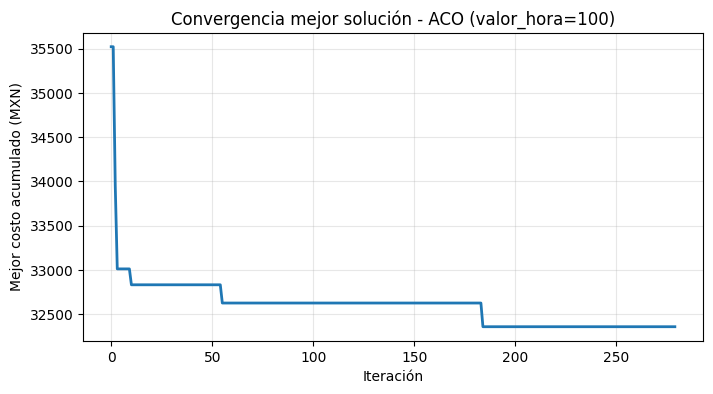

In [21]:
# ==========================================================
# CELDA 11: Gráfica de convergencia (mejor costo por iteración)
# ==========================================================
plt.figure(figsize=(8,4))
plt.plot(best_hist, lw=2)
plt.title(f"Convergencia mejor solución - {best_metodo} (valor_hora={best_vh})")
plt.xlabel("Iteración")
plt.ylabel("Mejor costo acumulado (MXN)")
plt.grid(True, alpha=0.3)
plt.show()

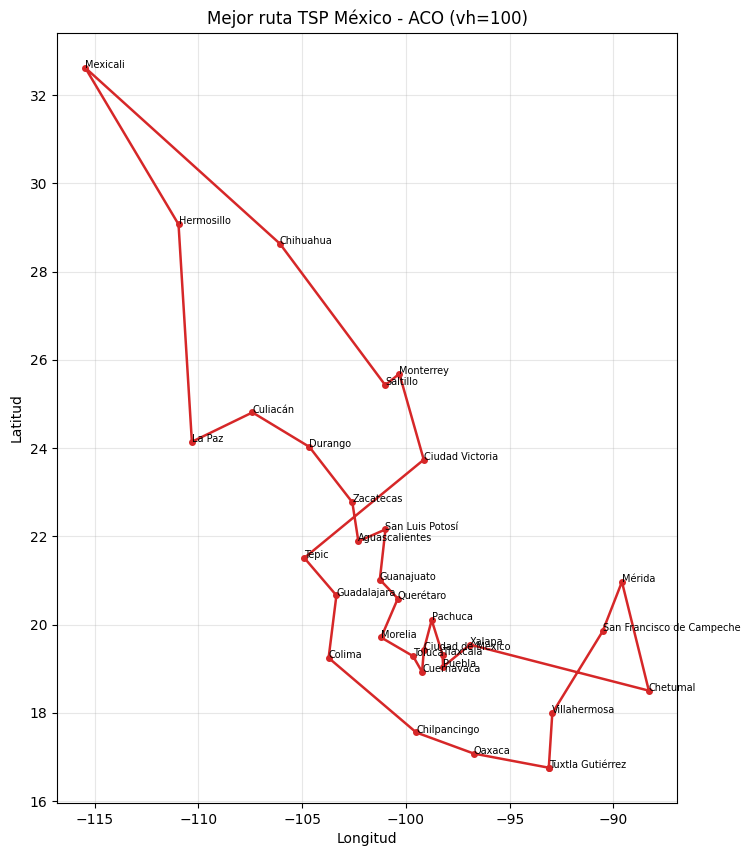

In [22]:
# ==========================================================
# CELDA 12: Dibujar ruta final en "mapa" (lat/lon)
# ==========================================================
def plot_ruta_estatica(route, df, title="Ruta"):
    lats = [df.loc[i, "lat"] for i in route] + [df.loc[route[0], "lat"]]
    lons = [df.loc[i, "lon"] for i in route] + [df.loc[route[0], "lon"]]

    plt.figure(figsize=(8,10))
    plt.plot(lons, lats, "-o", color="tab:red", lw=1.8, ms=4)
    plt.title(title)
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.grid(alpha=0.3)

    # etiqueta ligera (puedes comentar si se ve saturado)
    for i in route:
        plt.text(df.loc[i,"lon"], df.loc[i,"lat"], df.loc[i,"ciudad"], fontsize=7)

    plt.show()

plot_ruta_estatica(best_route, df_ciudades, title=f"Mejor ruta TSP México - {best_metodo} (vh={best_vh})")

In [23]:
# ==========================================================
# CELDA 13: GIF animado de la mejor ruta
# ==========================================================
def crear_gif_ruta(route, df, out_gif="outputs/gifs/tsp_mexico_best.gif"):
    import os
    os.makedirs("outputs/gifs", exist_ok=True)

    lats = [df.loc[i, "lat"] for i in route] + [df.loc[route[0], "lat"]]
    lons = [df.loc[i, "lon"] for i in route] + [df.loc[route[0], "lon"]]

    fig, ax = plt.subplots(figsize=(8,10))
    ax.scatter(df["lon"], df["lat"], c="black", s=18)
    ax.set_title("Construcción de la mejor ruta en México")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.grid(alpha=0.3)

    line, = ax.plot([], [], color="red", lw=2)
    point, = ax.plot([], [], "ro", ms=5)

    def init():
        line.set_data([], [])
        point.set_data([], [])
        return line, point

    def update(k):
        x = lons[:k+1]
        y = lats[:k+1]
        line.set_data(x, y)
        point.set_data([x[-1]], [y[-1]])
        return line, point

    anim = FuncAnimation(fig, update, frames=len(lons), init_func=init, blit=True, interval=350)
    anim.save(out_gif, writer=PillowWriter(fps=3))
    plt.close(fig)
    return out_gif

gif_path = crear_gif_ruta(best_route, df_ciudades, out_gif="outputs/gifs/tsp_mexico_best.gif")
print("GIF guardado en:", gif_path)

GIF guardado en: outputs/gifs/tsp_mexico_best.gif
